In [10]:
import numpy as np
import pandas as pd

In [11]:
pd.read_csv("cleaned_dataset.csv")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9784,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9785,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9786,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9787,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [12]:
# 1. Install/import required libraries
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [13]:
# 2. Load the cleaned dataset
# The notebook first looks for common cleaned-data filenames.
# If automatic selection is wrong, change DATA_FILE to your filename.

DATA_FILE = None   # Example: "cleaned_data.csv"

candidates = []
for pattern in ["*.csv", "*.xlsx", "*.xls"]:
    candidates.extend(glob.glob(pattern))

preferred = [
    f for f in candidates
    if any(k in os.path.basename(f).lower() for k in
           ["clean", "task1", "task_1", "sales", "superstore"])
]

if DATA_FILE is None:
    if preferred:
        DATA_FILE = preferred[0]
    elif candidates:
        DATA_FILE = candidates[0]
    else:
        raise FileNotFoundError(
            "No CSV/XLSX file found. Put your cleaned dataset in the same folder as this notebook."
        )

print("Using file:", DATA_FILE)

if DATA_FILE.lower().endswith(".csv"):
    df = pd.read_csv(DATA_FILE)
else:
    df = pd.read_excel(DATA_FILE)

print("Shape:", df.shape)
display(df.head())

Using file: cleaned_dataset.csv
Shape: (9789, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [14]:
# 3. Basic preparation
df.columns = [str(c).strip() for c in df.columns]
df = df.drop_duplicates().copy()

# Convert columns that look like dates
for col in df.columns:
    if df[col].dtype == "object":
        converted = pd.to_datetime(df[col], errors="coerce")
        if converted.notna().mean() >= 0.70:
            df[col] = converted

print("Rows:", len(df))
print("Columns:", list(df.columns))
display(df.info())

Rows: 9789
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9789 entries, 0 to 9788
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9789 non-null   int64  
 1   Order ID       9789 non-null   object 
 2   Order Date     9789 non-null   object 
 3   Ship Date      9789 non-null   object 
 4   Ship Mode      9789 non-null   object 
 5   Customer ID    9789 non-null   object 
 6   Customer Name  9789 non-null   object 
 7   Segment        9789 non-null   object 
 8   Country        9789 non-null   object 
 9   City           9789 non-null   object 
 10  State          9789 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9789 non-nu

None

## Part A – Descriptive Statistics

In [4]:
# 4. Descriptive statistics
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if not numeric_cols:
    raise ValueError("No numeric columns were found in the dataset.")

desc = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": [df[c].mode().iloc[0] if not df[c].mode().empty else np.nan for c in numeric_cols],
    "Std_Dev": df[numeric_cols].std(),
    "Skewness": df[numeric_cols].skew()
}).round(3)

display(desc)

,Mean,Median,Mode,Std_Dev,Skewness
Row ID,4896.706,4896.000,1.00,2827.487,0.001
Postal Code,55273.322,58103.000,10035.00,32041.223,-0.131
Sales,230.116,54.384,12.96,625.302,13.054


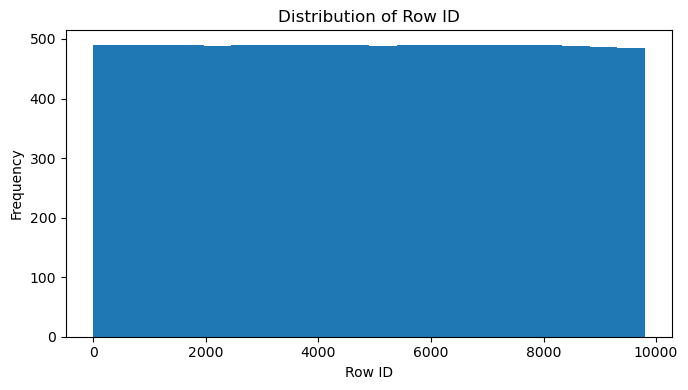

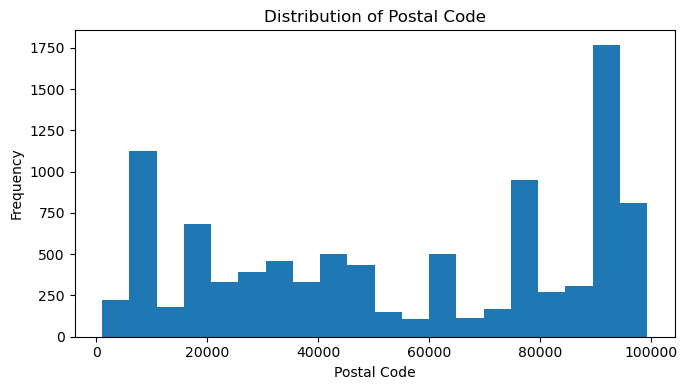

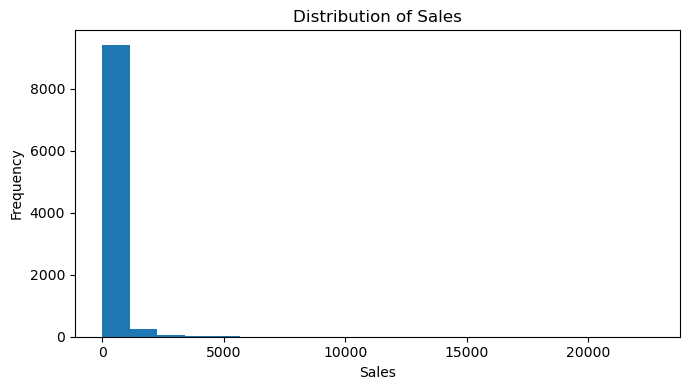

In [15]:
# 5. Distribution plots
for col in numeric_cols[:6]:
    fig, ax = plt.subplots(figsize=(7,4))
    ax.hist(df[col].dropna(), bins=20)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Part B – Hypothesis Testing
### T-test
Compare the mean of a numeric business measure between two groups.

### Chi-square test


In [16]:
# 6. Independent two-sample t-test
# Prefer Sales as the business measure; otherwise use the first numeric column.
target_candidates = [c for c in df.columns if c.lower() in ["sales", "revenue", "amount", "profit"]]
measure = target_candidates[0] if target_candidates else numeric_cols[0]

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
if len(categorical_cols) == 0:
    # Date-derived groups can still provide a two-group comparison
    date_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if date_cols:
        temp = df[[measure, date_cols[0]]].dropna().copy()
        temp["Group"] = temp[date_cols[0]].dt.month % 2
        groups = [g[measure].values for _, g in temp.groupby("Group") if len(g) > 1]
    else:
        groups = []
else:
    group_col = min(categorical_cols, key=lambda c: df[c].nunique())
    levels = df[group_col].dropna().unique()[:2]
    groups = [df.loc[df[group_col] == lev, measure].dropna().values for lev in levels]

if len(groups) == 2 and all(len(g) > 1 for g in groups):
    t_stat, p_value = stats.ttest_ind(groups[0], groups[1], equal_var=False)
    print(f"Measure: {measure}")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value = {p_value:.6f}")
    print("Result:", "Significant difference (p < 0.05)" if p_value < 0.05
          else "No statistically significant difference (p >= 0.05)")
else:
    print("T-test skipped: suitable two-group data was not available.")

T-test skipped: suitable two-group data was not available.


In [17]:
# 7. Chi-square test of independence
if len(categorical_cols) >= 2:
    # Select two categorical columns with manageable numbers of levels
    pairs = []
    for i in range(len(categorical_cols)):
        for j in range(i+1, len(categorical_cols)):
            a, b = categorical_cols[i], categorical_cols[j]
            if 2 <= df[a].nunique() <= 20 and 2 <= df[b].nunique() <= 20:
                pairs.append((a,b))
    if pairs:
        c1, c2 = pairs[0]
        table = pd.crosstab(df[c1], df[c2])
        chi2, p, dof, expected = stats.chi2_contingency(table)
        print(f"Variables: {c1} vs {c2}")
        print(f"Chi-square = {chi2:.4f}, dof = {dof}, p-value = {p:.6f}")
        print("Result:", "Significant association (p < 0.05)" if p < 0.05
              else "No statistically significant association (p >= 0.05)")
        display(table)
    else:
        print("Chi-square skipped: no suitable categorical pair.")
else:
    print("Chi-square skipped: fewer than two categorical columns.")

Variables: Ship Mode vs Segment
Chi-square = 25.7742, dof = 6, p-value = 0.000245
Result: Significant association (p < 0.05)


Segment,Consumer,Corporate,Home Office
Ship Mode,,,
First Class,755,468,278
Same Day,312,114,112
Second Class,1002,589,310
Standard Class,3027,1777,1045


In [18]:
# 8. 95% confidence interval for the mean of the main business measure
x = df[measure].dropna()
n = len(x)
mean_x = x.mean()
se = stats.sem(x)
ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean_x, scale=se)

print(f"Measure: {measure}")
print(f"Mean = {mean_x:.3f}")
print(f"95% Confidence Interval = ({ci_low:.3f}, {ci_high:.3f})")

Measure: Sales
Mean = 230.116
95% Confidence Interval = (217.728, 242.505)


## Part C – Time-Series Analysis

In [19]:
# 9. Time-series analysis
date_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()

if date_cols:
    date_col = date_cols[0]
    ts = df[[date_col, measure]].dropna().copy()
    ts = ts.set_index(date_col).sort_index()

    # Choose monthly frequency for broad sales datasets
    ts_monthly = ts[measure].resample("MS").sum()

    print("Date column:", date_col)
    print("Monthly time-series rows:", len(ts_monthly))
    display(ts_monthly.head())

    # Trend + moving average
    ma_window = min(3, max(2, len(ts_monthly)//4)) if len(ts_monthly) >= 4 else 2
    ts_monthly_ma = ts_monthly.rolling(ma_window).mean()

    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(ts_monthly.index, ts_monthly.values, label="Actual")
    ax.plot(ts_monthly_ma.index, ts_monthly_ma.values, label=f"{ma_window}-month Moving Average")
    ax.set_title(f"{measure} – Time Series and Moving Average")
    ax.set_xlabel("Date")
    ax.set_ylabel(measure)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Decomposition when enough observations are available
    try:
        from statsmodels.tsa.seasonal import seasonal_decompose
        period = 12 if len(ts_monthly) >= 24 else (4 if len(ts_monthly) >= 8 else 2)
        decomposition = seasonal_decompose(ts_monthly, model="additive", period=period)
        decomposition.plot()
        plt.suptitle(f"{measure} – Trend, Seasonality and Residuals", y=1.02)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Seasonal decomposition could not be produced:", e)

    # Simple next-period moving-average forecast
    forecast = ts_monthly.tail(ma_window).mean()
    print(f"Simple moving-average forecast for next month: {forecast:.3f}")
else:
    print("No date column found. Time-series analysis skipped as allowed by the task.")

No date column found. Time-series analysis skipped as allowed by the task.


## Part D – Customer Segmentation (K-Means)
Features are scaled using `StandardScaler`. The elbow method is used to select a practical K, followed by K-Means clustering and PCA visualization.

In [20]:
# 10. Build customer-level features
customer_candidates = [c for c in df.columns if c.lower() in
                       ["customer id", "customer_id", "customer", "customerid"]]

if customer_candidates:
    customer_col = customer_candidates[0]
    num_for_customer = [c for c in numeric_cols if c != customer_col]

    # Customer-level aggregation
    agg_dict = {c: "mean" for c in num_for_customer[:8]}
    if measure in num_for_customer:
        agg_dict[measure] = "sum"

    customer_df = df.groupby(customer_col).agg(agg_dict)
    print("Customer identifier:", customer_col)
    print("Customer-level shape:", customer_df.shape)
else:
    customer_col = None
    customer_df = df[numeric_cols].copy()
    print("Customer ID not found; clustering is performed at row level.")

# Clean and select useful numeric features
customer_df = customer_df.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="all")
customer_df = customer_df.fillna(customer_df.median(numeric_only=True))

cluster_features = customer_df.select_dtypes(include=np.number).columns.tolist()
# Remove ID-like columns where possible
cluster_features = [
    c for c in cluster_features
    if customer_df[c].nunique() > 2 and
       "id" not in c.lower()
]

if len(cluster_features) < 2:
    raise ValueError("At least two suitable numeric features are needed for clustering.")

X_cluster = customer_df[cluster_features].copy()
print("Clustering features:", cluster_features)
display(X_cluster.head())

Customer identifier: Customer ID
Customer-level shape: (793, 3)
Clustering features: ['Postal Code', 'Sales']


,Postal Code,Sales
Customer ID,,
AA-10315,66167.727273,5563.560
AA-10375,44294.200000,1056.390
AA-10480,50390.750000,1790.512
AA-10645,50655.111111,5086.935
AB-10015,86094.333333,886.156


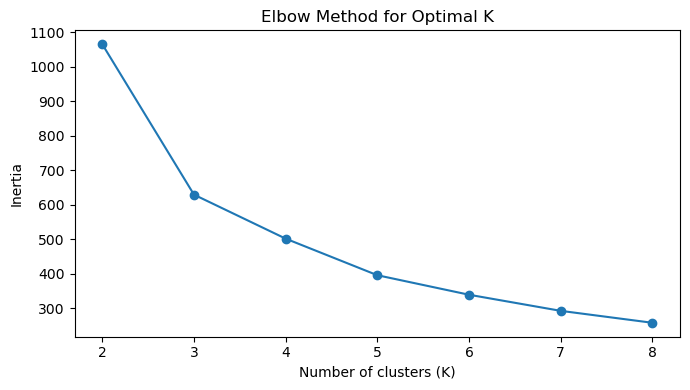

Selected K = 4


In [21]:
# 11. Elbow method
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

max_k = min(8, len(X_cluster)-1)
k_values = range(2, max_k+1)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(list(k_values), inertias, marker="o")
ax.set_title("Elbow Method for Optimal K")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_xticks(list(k_values))
plt.tight_layout()
plt.show()

# For a stable internship submission, use 4 clusters when possible.
optimal_k = 4 if len(X_cluster) >= 4 else max(2, len(X_cluster))
print("Selected K =", optimal_k)

In [22]:
# 12. Apply K-Means and profile segments
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = customer_df.groupby("Cluster")[cluster_features].mean().round(2)
cluster_sizes = customer_df["Cluster"].value_counts().sort_index()

print("Cluster sizes:")
display(cluster_sizes.rename("Customers"))

print("Cluster profile:")
display(cluster_profile)

Cluster sizes:


Cluster
0    284
1    210
2    246
3     53
Name: Customers, dtype: int64

Cluster profile:


,Postal Code,Sales
Cluster,,
0,39680.45,1609.34
1,57225.30,4127.61
2,70803.35,1614.81
3,51527.56,10028.57


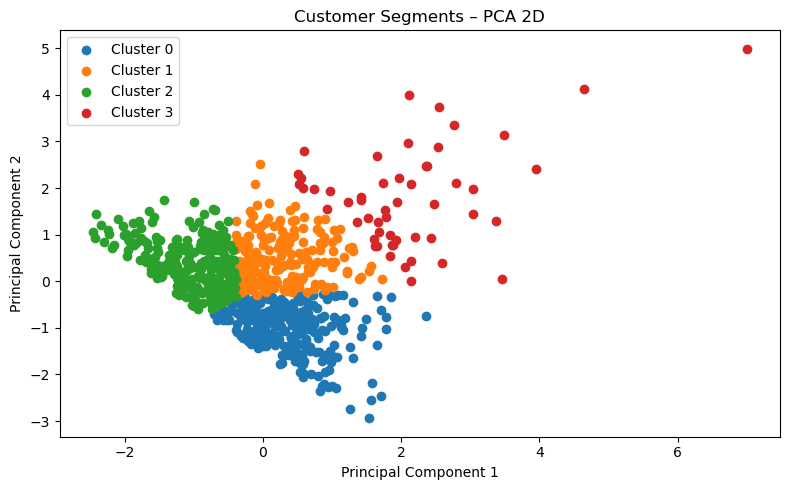

Explained variance ratio: [0.501 0.499]


In [23]:
# 13. PCA visualization of clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": customer_df["Cluster"].values
})

fig, ax = plt.subplots(figsize=(8,5))
for cluster in sorted(pca_df["Cluster"].unique()):
    part = pca_df[pca_df["Cluster"] == cluster]
    ax.scatter(part["PC1"], part["PC2"], label=f"Cluster {cluster}")
ax.set_title("Customer Segments – PCA 2D")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

In [ ]:
# 14. Automatic segment recommendations
means = cluster_profile.copy()

print("Segment recommendations:")
for cluster in means.index:
    row = means.loc[cluster]
    # Highest-valued features relative to all segment averages
    relative = (row / means.mean()).sort_values(ascending=False)
    strengths = list(relative.head(2).index)

    print(f"Cluster {cluster}:")
    print(f"  Main strengths: {', '.join(strengths)}")
    print("  Recommendation: target with offers/messages based on the segment's strongest behaviors.")

## Part E – Basic Predictive Model.

In [24]:
# 15. Prepare data for prediction
target_candidates = [c for c in df.columns if c.lower() in
                     ["sales", "revenue", "amount", "profit"]]
prediction_target = target_candidates[0] if target_candidates else measure

model_df = df.dropna(subset=[prediction_target]).copy()

# Add useful date components
for dcol in model_df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns:
    model_df[dcol + "_year"] = model_df[dcol].dt.year
    model_df[dcol + "_month"] = model_df[dcol].dt.month
    model_df[dcol + "_day"] = model_df[dcol].dt.day
    model_df[dcol + "_weekday"] = model_df[dcol].dt.dayofweek

X = model_df.drop(columns=[prediction_target]).copy()
y = model_df[prediction_target].astype(float)

# Drop datetime columns after extracting components
X = X.drop(columns=X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns)

# Remove obvious ID/high-cardinality identifier columns
for c in list(X.columns):
    if "id" in c.lower() and X[c].nunique() / max(len(X),1) > 0.5:
        X = X.drop(columns=[c])

# Keep usable columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Remove constant columns
numeric_features = [c for c in numeric_features if X[c].nunique(dropna=True) > 1]
categorical_features = [c for c in categorical_features if X[c].nunique(dropna=True) <= 30 and X[c].nunique(dropna=True) > 1]

X = X[numeric_features + categorical_features]

print("Prediction target:", prediction_target)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Prediction target: Sales
Numeric features: ['Postal Code']
Categorical features: ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']


In [25]:
# 16. Train/test split and Linear Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", __import__("sklearn").impute.SimpleImputer(strategy="median"))]), numeric_features),
        ("cat", Pipeline([
            ("imputer", __import__("sklearn").impute.SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"R² Score  : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

R² Score  : 0.1515
MAE       : 231.8790
RMSE      : 644.2252


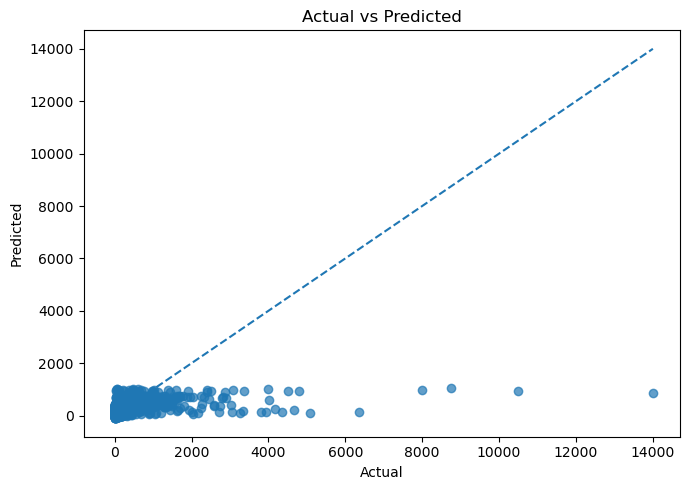

In [26]:
# 17. Actual vs predicted plot
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(y_test, pred, alpha=0.7)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title("Actual vs Predicted")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
plt.tight_layout()
plt.show()

In [27]:
# 18. Identify top important features from Linear Regression coefficients
try:
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    coefficients = model.named_steps["regressor"].coef_
    importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Absolute_Importance": np.abs(coefficients)
    }).sort_values("Absolute_Importance", ascending=False)

    print("Top 10 important features:")
    display(importance.head(10))
except Exception as e:
    print("Could not extract feature importance:", e)

Top 10 important features:


,Feature,Coefficient,Absolute_Importance
24,cat__Sub-Category_Furnishings,-432.605203,432.605203
26,cat__Sub-Category_Machines,400.803070,400.803070
15,cat__Sub-Category_Accessories,-382.200730,382.200730
21,cat__Sub-Category_Copiers,336.506022,336.506022
13,cat__Category_Office Supplies,-257.458419,257.458419
31,cat__Sub-Category_Tables,213.862967,213.862967
20,cat__Sub-Category_Chairs,212.871904,212.871904
29,cat__Sub-Category_Storage,183.788693,183.788693
28,cat__Sub-Category_Phones,-180.274983,180.274983
14,cat__Category_Technology,174.833380,174.833380


## Part F – Final Business Findings

In [28]:
# 19. Generate final findings for the report
print("="*70)
print("APEX PLANET TASK 4 – FINAL FINDINGS")
print("="*70)

print(f"1. Dataset contains {df.shape[0]} rows and {df.shape[1]} columns after basic preparation.")
print(f"2. Main business measure analyzed: {measure}. Mean = {df[measure].mean():.2f}.")

# Skewness insight
sk = df[measure].skew()
print(f"3. {measure} skewness = {sk:.3f} → " +
      ("right-skewed distribution." if sk > 0.5 else
       "left-skewed distribution." if sk < -0.5 else
       "approximately symmetric distribution."))

print(f"4. Customer/record segmentation used K = {optimal_k} clusters.")
print(f"5. Predictive model: Linear Regression with 80/20 train-test split.")
print(f"   R² = {r2:.3f}, MAE = {mae:.3f}, RMSE = {rmse:.3f}.")

if r2 >= 0.7:
    print("6. Model shows a strong explanatory/predictive fit on the test set.")
elif r2 >= 0.4:
    print("6. Model shows a moderate fit; additional features or models could improve it.")
else:
    print("6. Model fit is limited; additional features, transformations or nonlinear models may improve it.")

print("7. Business implication: use the customer clusters to tailor offers and prioritize high-value segments.")
print("8. Business implication: use the predictive model as a baseline for forecasting the selected business measure.")
print("="*70)

APEX PLANET TASK 4 – FINAL FINDINGS
1. Dataset contains 9789 rows and 18 columns after basic preparation.
2. Main business measure analyzed: Sales. Mean = 230.12.
3. Sales skewness = 13.054 → right-skewed distribution.
4. Customer/record segmentation used K = 4 clusters.
5. Predictive model: Linear Regression with 80/20 train-test split.
   R² = 0.152, MAE = 231.879, RMSE = 644.225.
6. Model fit is limited; additional features, transformations or nonlinear models may improve it.
7. Business implication: use the customer clusters to tailor offers and prioritize high-value segments.
8. Business implication: use the predictive model as a baseline for forecasting the selected business measure.
